In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv(r"C:\Downloads\Programming\Datasets\flipkart reviews\flipkart_product.csv", encoding = 'latin-1')

In [4]:
sample_reviews = {
    'review_id': range(1, 21),
    'product_name': ['Smartphone'] * 5 + ['Laptop'] * 5 + ['Headphones'] * 5 + ['Smartwatch'] * 5,
    'rating': [5, 4, 2, 5, 3, 5, 4, 1, 5, 3, 4, 5, 2, 4, 3, 5, 4, 2, 3, 5],
    'review_text': [
        'Excellent product! Works perfectly and great value for money.',
        'Good phone but battery life could be better.',
        'Disappointed with the camera quality. Not worth the price.',
        'Amazing features and fast delivery. Highly recommended!',
        'Average product, nothing special but does the job.',
        'Best laptop I ever bought! Super fast and lightweight.',
        'Good performance but gets hot during heavy usage.',
        'Terrible experience. Laptop stopped working after 2 weeks.',
        'Perfect for my needs. Great build quality and display.',
        'Decent laptop but overpriced for the specifications.',
        'Sound quality is incredible! Very comfortable to wear.',
        'Excellent noise cancellation. Worth every penny.',
        'Poor build quality, broke within a month.',
        'Great bass and clear sound. Happy with purchase.',
        'Okay headphones but not as good as advertised.',
        'Love this smartwatch! Tracks everything accurately.',
        'Good fitness features and battery lasts long.',
        'Not compatible with my phone. Very frustrating.',
        'Nice design but limited app support.',
        'Perfect smartwatch! Stylish and functional.'
    ]
}

In [5]:
df = pd.DataFrame(sample_reviews)
print("Sample Reviews Dataset:")
print(df.head())
print(f"\nTotal Reviews: {len(df)}")

Sample Reviews Dataset:
   review_id product_name  rating  \
0          1   Smartphone       5   
1          2   Smartphone       4   
2          3   Smartphone       2   
3          4   Smartphone       5   
4          5   Smartphone       3   

                                         review_text  
0  Excellent product! Works perfectly and great v...  
1       Good phone but battery life could be better.  
2  Disappointed with the camera quality. Not wort...  
3  Amazing features and fast delivery. Highly rec...  
4  Average product, nothing special but does the ...  

Total Reviews: 20


In [6]:
def clean_text(text):
    """Clean and preprocess review text"""
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

In [7]:
df['cleaned_text'] = df['review_text'].apply(clean_text)
print("Text Cleaning Complete!")
print(df[['review_text', 'cleaned_text']].head(3))

Text Cleaning Complete!
                                         review_text  \
0  Excellent product! Works perfectly and great v...   
1       Good phone but battery life could be better.   
2  Disappointed with the camera quality. Not wort...   

                                        cleaned_text  
0  excellent product works perfectly and great va...  
1        good phone but battery life could be better  
2  disappointed with the camera quality not worth...  


In [8]:
def get_sentiment(text):
    """Analyze sentiment using TextBlob"""
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # Classify sentiment
    if polarity > 0.1:
        sentiment = 'Positive'
    elif polarity < -0.1:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'

    return pd.Series([polarity, subjectivity, sentiment])

df[['polarity', 'subjectivity', 'sentiment']] = df['cleaned_text'].apply(get_sentiment)

print("Sentiment Analysis Results:")
print(df[['review_text', 'rating', 'polarity', 'sentiment']].head(10))

Sentiment Analysis Results:
                                         review_text  rating  polarity  \
0  Excellent product! Works perfectly and great v...       5  0.933333   
1       Good phone but battery life could be better.       4  0.600000   
2  Disappointed with the camera quality. Not wort...       2 -0.450000   
3  Amazing features and fast delivery. Highly rec...       5  0.320000   
4  Average product, nothing special but does the ...       3  0.103571   
5  Best laptop I ever bought! Super fast and ligh...       5  0.511111   
6  Good performance but gets hot during heavy usage.       4  0.250000   
7  Terrible experience. Laptop stopped working af...       1 -1.000000   
8  Perfect for my needs. Great build quality and ...       5  0.900000   
9  Decent laptop but overpriced for the specifica...       3  0.166667   

  sentiment  
0  Positive  
1  Positive  
2  Negative  
3  Positive  
4  Positive  
5  Positive  
6  Positive  
7  Negative  
8  Positive  
9  Positive  


In [9]:
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:")
print(sentiment_counts)
print(f"\nPositive Reviews: {sentiment_counts.get('Positive', 0)} ({sentiment_counts.get('Positive', 0)/len(df)*100:.1f}%)")
print(f"Negative Reviews: {sentiment_counts.get('Negative', 0)} ({sentiment_counts.get('Negative', 0)/len(df)*100:.1f}%)")
print(f"Neutral Reviews: {sentiment_counts.get('Neutral', 0)} ({sentiment_counts.get('Neutral', 0)/len(df)*100:.1f}%)")


Sentiment Distribution:
sentiment
Positive    16
Negative     4
Name: count, dtype: int64

Positive Reviews: 16 (80.0%)
Negative Reviews: 4 (20.0%)
Neutral Reviews: 0 (0.0%)


Text(0, 0.5, '')

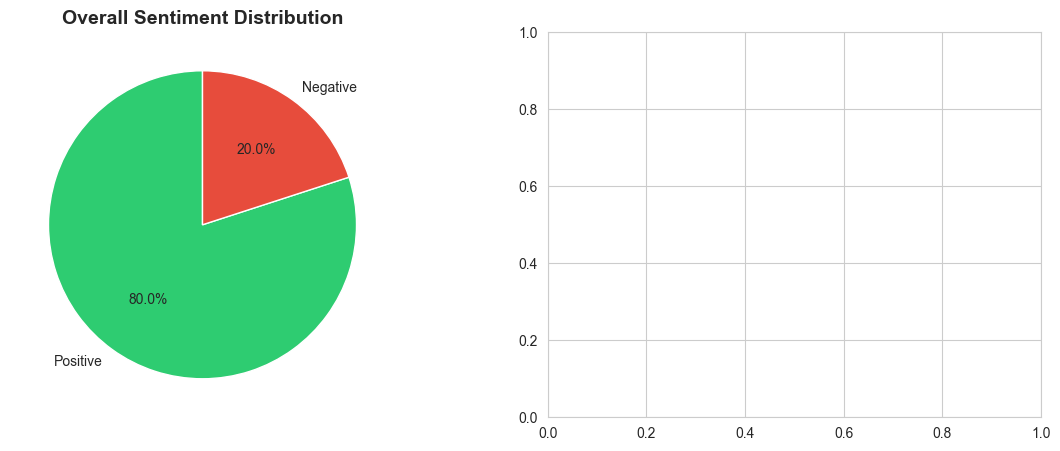

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c', '#95a5a6']
sentiment_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

In [11]:
sentiment_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Sentiment Frequency', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

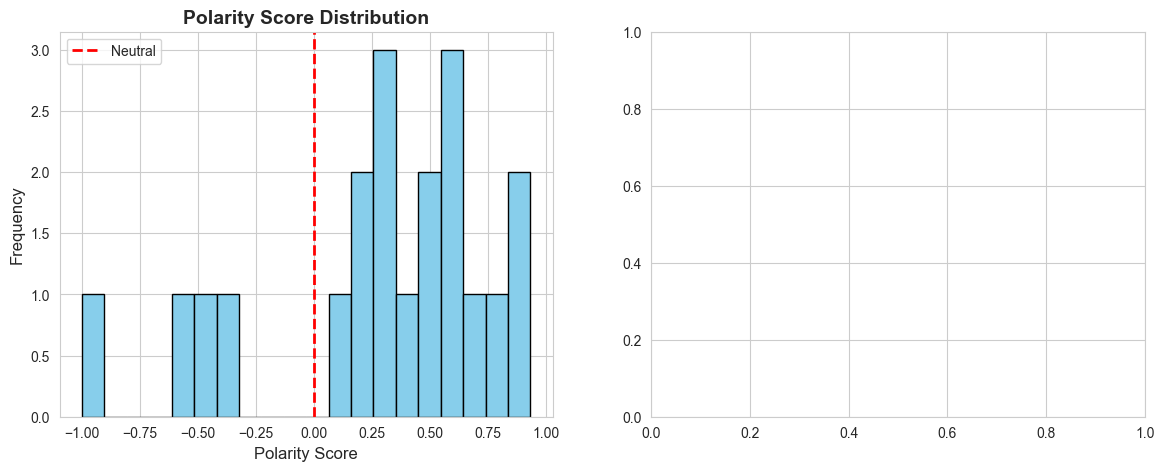

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['polarity'], bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0].set_title('Polarity Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Polarity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

In [13]:
axes[1].hist(df['subjectivity'], bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Subjectivity Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subjectivity Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

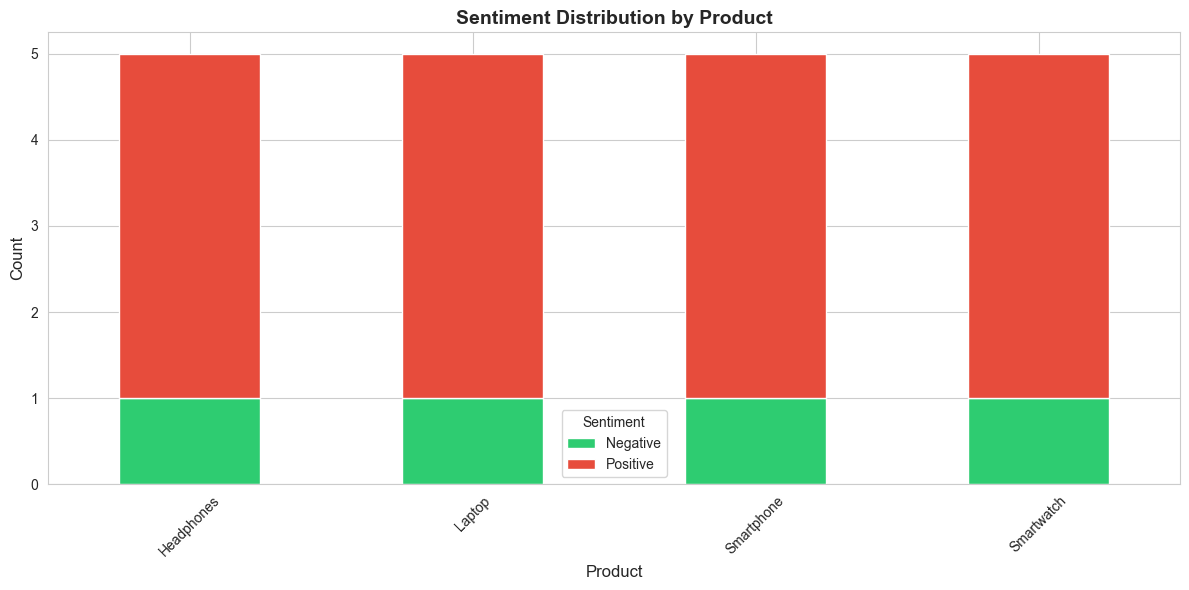

In [14]:
product_sentiment = pd.crosstab(df['product_name'], df['sentiment'])
product_sentiment.plot(kind='bar', stacked=True, color=colors, figsize=(12, 6))
plt.title('Sentiment Distribution by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

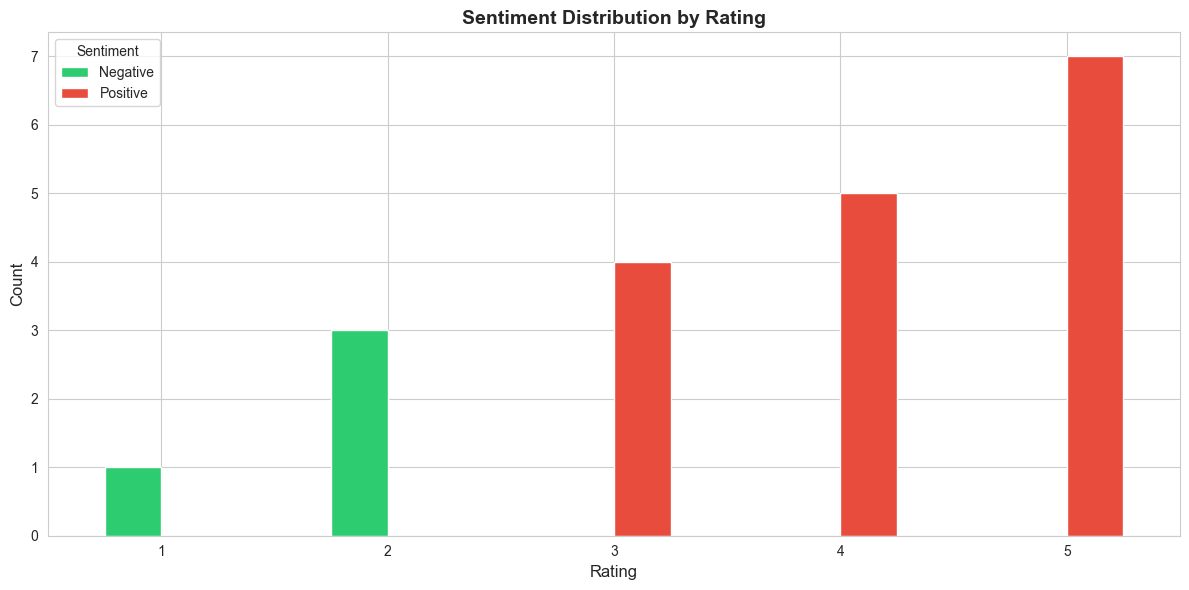

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
df.groupby(['rating', 'sentiment']).size().unstack(fill_value=0).plot(kind='bar', ax=ax, color=colors)
ax.set_title('Sentiment Distribution by Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Sentiment')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

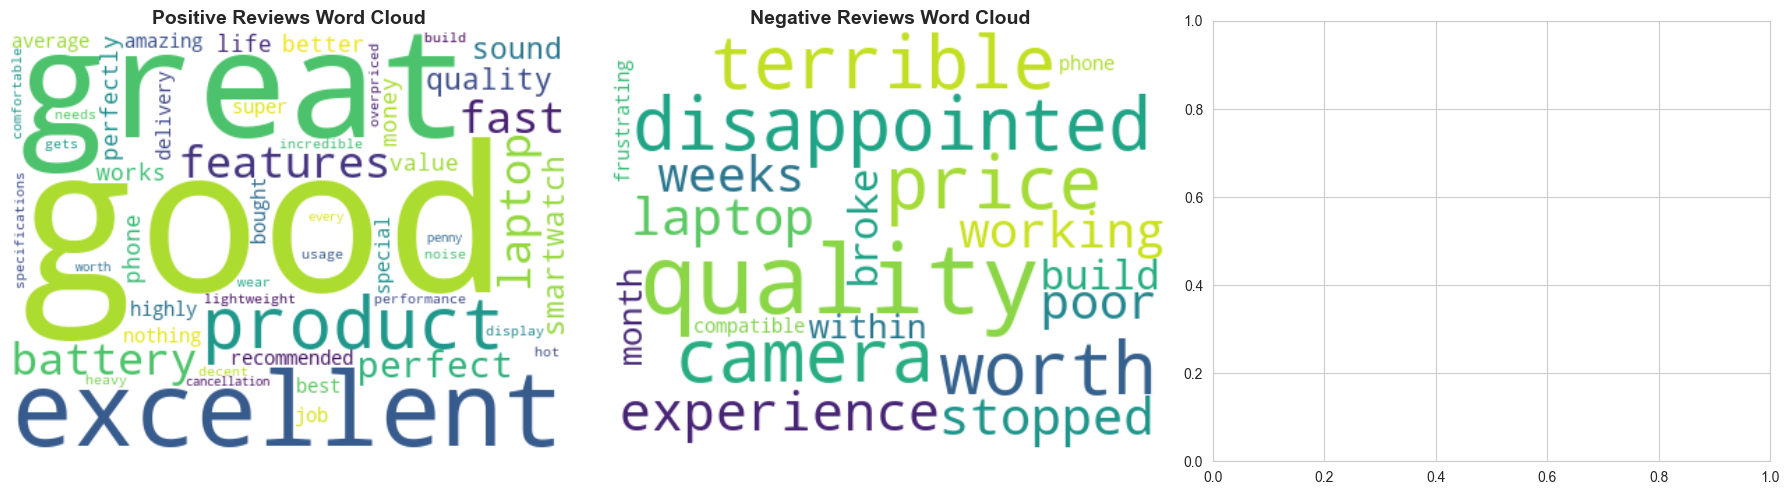

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, sentiment in enumerate(['Positive', 'Negative', 'Neutral']):
    if sentiment in df['sentiment'].values:
        text = ' '.join(df[df['sentiment'] == sentiment]['cleaned_text'])
        wordcloud = WordCloud(width=400, height=300, background_color='white',
                             colormap='viridis', max_words=50).generate(text)

        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'{sentiment} Reviews Word Cloud', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [17]:
def get_top_words(sentiment_type, n=10):
    """Get top n words for a specific sentiment"""
    text = ' '.join(df[df['sentiment'] == sentiment_type]['cleaned_text'])
    words = text.split()
    # Filter out common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                  'of', 'with', 'is', 'it', 'this', 'that', 'very', 'so', 'my', 'i'}
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    return Counter(filtered_words).most_common(n)

print("Top 10 Words in Positive Reviews:")
print(get_top_words('Positive', 10))
print("\nTop 10 Words in Negative Reviews:")
print(get_top_words('Negative', 10))

Top 10 Words in Positive Reviews:
[('good', 4), ('great', 3), ('excellent', 2), ('product', 2), ('battery', 2), ('features', 2), ('fast', 2), ('laptop', 2), ('perfect', 2), ('quality', 2)]

Top 10 Words in Negative Reviews:
[('quality', 2), ('not', 2), ('disappointed', 1), ('camera', 1), ('worth', 1), ('price', 1), ('terrible', 1), ('experience', 1), ('laptop', 1), ('stopped', 1)]


In [18]:
summary = df.groupby('sentiment').agg({
    'polarity': ['mean', 'min', 'max'],
    'subjectivity': ['mean', 'min', 'max'],
    'rating': ['mean', 'count']
}).round(3)

print("\nSummary Statistics by Sentiment:")
print(summary)


Summary Statistics by Sentiment:
          polarity               subjectivity             rating      
              mean    min    max         mean    min  max   mean count
sentiment                                                             
Negative    -0.592 -1.000 -0.400        0.756  0.425  1.0  1.750     4
Positive     0.489  0.104  0.933        0.657  0.486  1.0  4.188    16


In [19]:
product_summary = df.groupby('product_name').agg({
    'sentiment': lambda x: x.value_counts().to_dict(),
    'polarity': 'mean',
    'rating': 'mean'
}).round(3)

print("\nProduct-wise Summary:")
print(product_summary)


Product-wise Summary:
                                   sentiment  polarity  rating
product_name                                                  
Headphones    {'Positive': 4, 'Negative': 1}     0.369     3.6
Laptop        {'Positive': 4, 'Negative': 1}     0.166     3.6
Smartphone    {'Positive': 4, 'Negative': 1}     0.301     3.8
Smartwatch    {'Positive': 4, 'Negative': 1}     0.254     3.8


In [20]:
output_df = df[['review_id', 'product_name', 'rating', 'review_text',
                'polarity', 'subjectivity', 'sentiment']]
output_df.to_csv('sentiment_analysis_results.csv', index=False)
print("Results saved to 'sentiment_analysis_results.csv'")

Results saved to 'sentiment_analysis_results.csv'
